In [3]:
!python -m pip --version

pip 25.1.1 from C:\Program Files\Python313\Lib\site-packages\pip (python 3.13)



In [4]:
!python -m pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.0-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using 


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!python -m pip show pandas

Name: pandas
Version: 3.0.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-2026, Open source contributors.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contribut

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything is working!")

Everything is working!


In [3]:
import os

print(os.getcwd())

C:\Users\SCP\Documents\Titanic project\Data


In [6]:
df = pd.read_csv("train.csv")

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Titanic Dataset Analysis

## Data Exploration

In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [13]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.drop("Cabin", axis=1, inplace=True)

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Question 1: How many passengers survived?

In [16]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

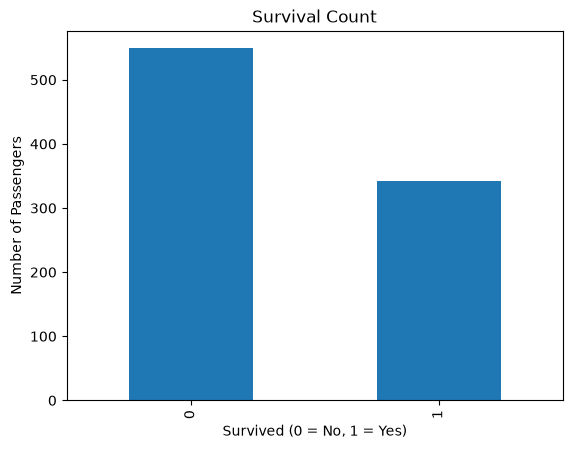

In [17]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Out of 891 passengers, 549 did not survive while 342 survived.
This indicates that the overall survival rate on the Titanic was lower than the death rate.

## Question 2: Did women survive more than men?

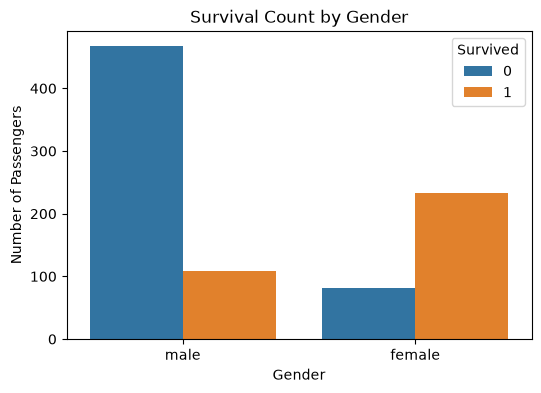

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The graph shows that female passengers had a much higher survival rate than male passengers. A large number of male passengers did not survive, while many female passengers survived.

A possible explanation is that during the Titanic disaster, women and children were often given priority when boarding the limited lifeboats. As a result, many men remained on the ship while helping with the evacuation, which may have contributed to the lower survival rate among male passengers.

## Question 3: Did passenger class affect survival?

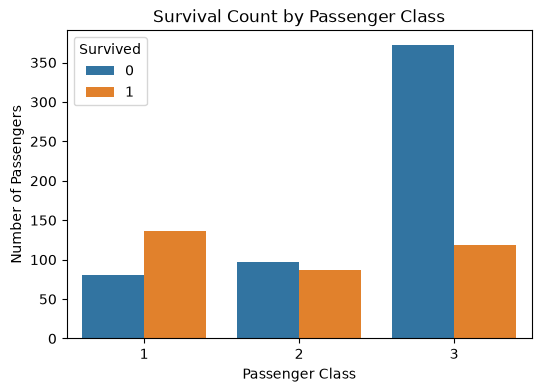

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The graph shows that passenger class had a significant impact on survival. First-class passengers had the highest survival rate, while third-class passengers experienced the highest number of deaths. Second-class passengers had a moderate survival rate.

A possible explanation is that first-class passengers were located closer to the lifeboats and had easier access to evacuation routes. In contrast, many third-class passengers were located on the lower decks, making it more difficult for them to reach the lifeboats during the emergency.

## Question 4: Did Age Affect Survival?

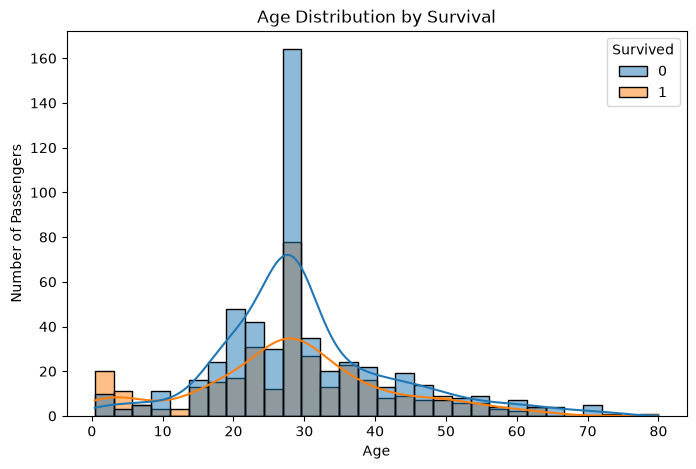

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The age distribution shows that most passengers were young adults between approximately 20 and 35 years of age. The highest number of survivors is also concentrated within this age group.

The number of passengers decreases as age increases, resulting in fewer survivors and non-survivors among older passengers. Based on this graph alone, we cannot conclude whether children had a higher survival rate because it displays the number of passengers rather than the proportion of survivors within each age group.

## Question 5: Did the ticket fare affect survival?

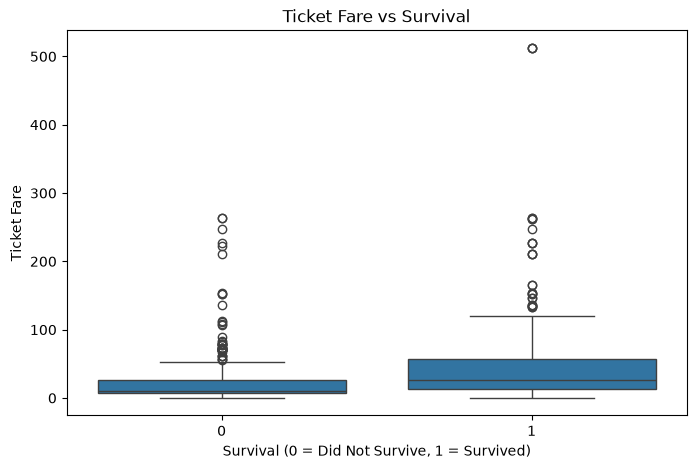

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Ticket Fare vs Survival")
plt.xlabel("Survival (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Ticket Fare")

plt.show()

### Observation

Passengers who survived generally paid higher ticket fares than those who did not survive. This suggests that passengers with more expensive tickets had a better chance of survival, possibly because they were more likely to travel in first class and had easier access to lifeboats.

## Question 6: Did Family Size Affect Survival?

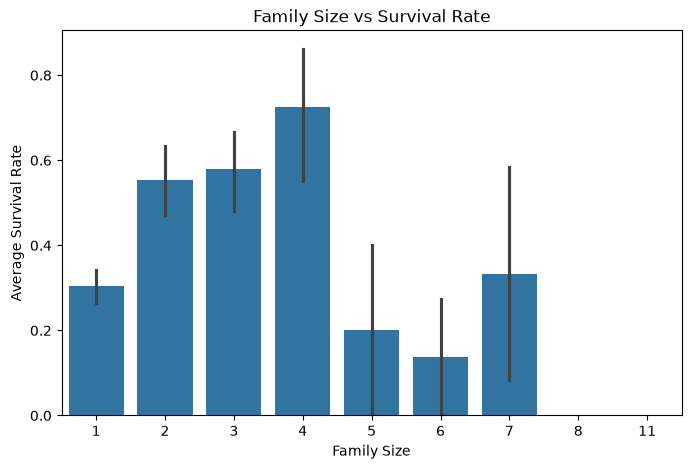

In [24]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(8,5))

sns.barplot(x="FamilySize", y="Survived", data=df)

plt.title("Family Size vs Survival Rate")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")

plt.show()

### Observation

Passengers travelling with small families generally had a higher survival rate than those travelling alone or in very large families. This suggests that a moderate family size may have improved the chances of survival.

## Question 7: Survival by Embarkation Port

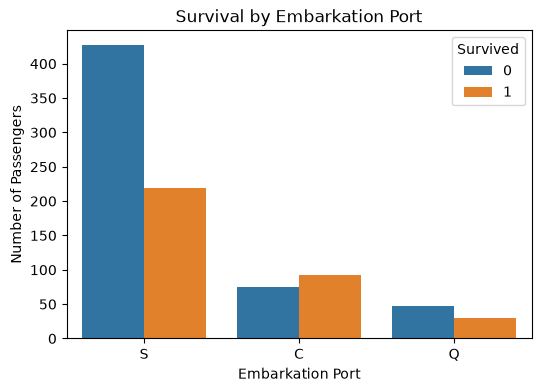

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="Embarked", hue="Survived", data=df)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Passengers who boarded from Cherbourg (C) showed a higher survival rate compared to those who boarded from Southampton (S) and Queenstown (Q). Southampton had the highest number of passengers and also the highest number of deaths.

## Question 8: Correlation Between Features

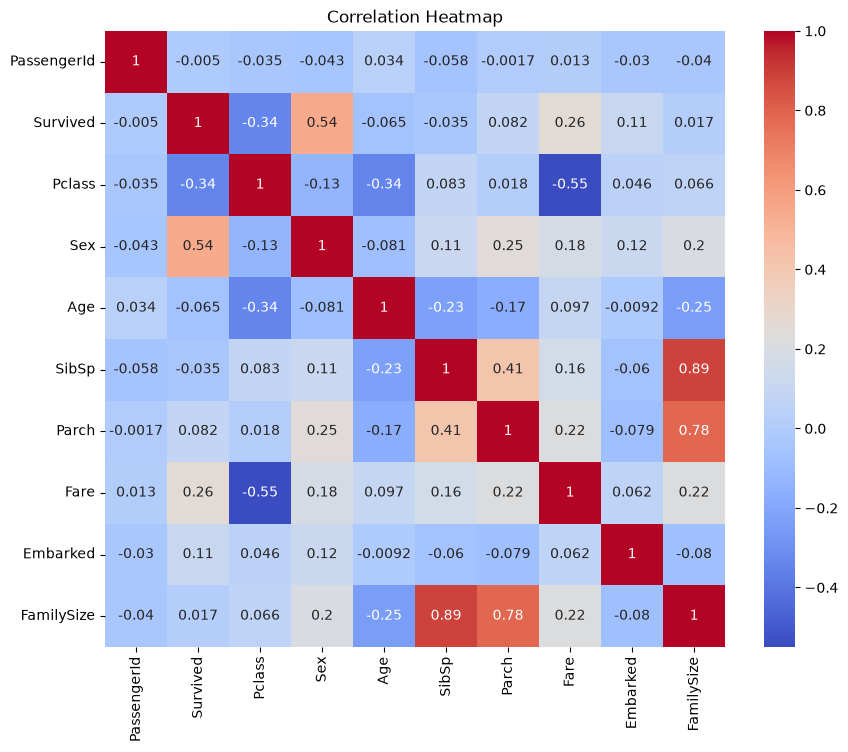

In [26]:
df_encoded = df.copy()

df_encoded["Sex"] = df_encoded["Sex"].map({"male": 0, "female": 1})
df_encoded["Embarked"] = df_encoded["Embarked"].map({"S": 0, "C": 1, "Q": 2})

plt.figure(figsize=(10,8))

sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that gender (Sex) and passenger class (Pclass) have the strongest relationship with survival. Female passengers and those travelling in higher classes were more likely to survive. Most other features have only weak correlations with survival.

In [27]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [28]:
features = ["Pclass","Sex","Age","Fare"]

In [29]:
X = df[features]

y = df["Survived"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [32]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
predictions = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 0.8044692737430168


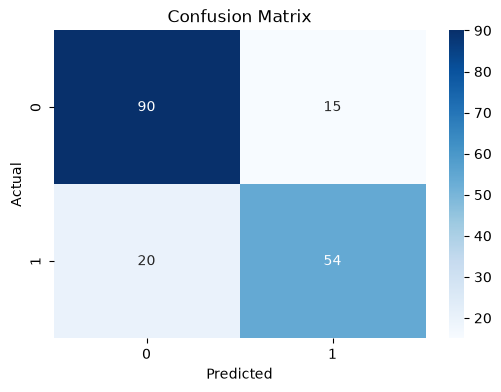

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix shows how well the model classified passengers into survived and non-survived categories. Most predictions were correct, although a few passengers were incorrectly classified. Overall, the model performed well with an accuracy of around 80%.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



# Final Conclusion

This project explored the Titanic passenger dataset to understand the factors that influenced survival. The analysis showed that gender, passenger class, ticket fare, and age were important factors affecting survival. Female passengers and first-class passengers had higher survival rates, while third-class passengers experienced more deaths. A Logistic Regression model was developed to predict passenger survival, achieving approximately 80% accuracy. This project demonstrates the complete data science workflow, including data cleaning, exploratory data analysis, visualization, feature engineering, and machine learning.